In [1]:
!pip install lightgbm pandas pyarrow matplotlib -q

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os
import gc
import math
import shutil
import datetime

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq

print("He thong LightGBM da san sang.")

Mounted at /content/drive
He thong LightGBM da san sang.


In [2]:
BASE_PATH = "/content/drive/MyDrive/HM-DATA/"

FEATURE_DIR = BASE_PATH + "outputs_v2/features/"
MODEL_DIR = BASE_PATH + "outputs_v2/models/"
PRED_DIR = BASE_PATH + "outputs_v2/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

TRAIN_FEATURE_PATH = FEATURE_DIR + "train_features.parquet"
TEST_FEATURE_PATH = FEATURE_DIR + "test_features.parquet"

MODEL_PATH = MODEL_DIR + "lightgbm_binary_model.txt"
IMPORTANCE_PATH = MODEL_DIR + "feature_importance.csv"
METRIC_PATH = MODEL_DIR + "metrics_lightgbm_binary.csv"

LOCAL_PREDS_PATH = "/content/test_predictions_lgbm.parquet"
DRIVE_PREDS_PATH = PRED_DIR + "test_predictions_lgbm.parquet"

DRIVE_TRANS = BASE_PATH + "processed_v2/cleaned_transactions.parquet"
DRIVE_CUST_RAW = BASE_PATH + "raw/customers.csv"

print("Train feature:", TRAIN_FEATURE_PATH)
print("Test feature :", TEST_FEATURE_PATH)
print("Model path   :", MODEL_PATH)
print("Pred path    :", DRIVE_PREDS_PATH)

Train feature: /content/drive/MyDrive/HM-DATA/outputs_v2/features/train_features.parquet
Test feature : /content/drive/MyDrive/HM-DATA/outputs_v2/features/test_features.parquet
Model path   : /content/drive/MyDrive/HM-DATA/outputs_v2/models/lightgbm_binary_model.txt
Pred path    : /content/drive/MyDrive/HM-DATA/outputs_v2/predictions/test_predictions_lgbm.parquet


In [3]:
id_cols = ["customer_id", "article_id", "label"]

categorical_features = [
    "item_product_type",
    "item_colour_group"
]

dataset_schema = ds.dataset(TRAIN_FEATURE_PATH, format="parquet").schema
all_columns = dataset_schema.names

features = [col for col in all_columns if col not in id_cols]

missing_cat_cols = [col for col in categorical_features if col not in features]
if missing_cat_cols:
    raise ValueError(f"Thieu categorical features: {missing_cat_cols}")

print("So feature:", len(features))
print("Categorical features:", categorical_features)

for col in features:
    print(col)

So feature: 41
Categorical features: ['item_product_type', 'item_colour_group']
item_colour_group
item_product_type
als_score
itemcf_score
source_count
age
item_total_sales
item_avg_price
item_repurchase_ratio
item_online_ratio
item_days_since_first_sale
item_days_since_last_sale
item_active_days
item_price_drop_ratio
user_total_purchases
user_avg_price
user_price_std
user_unique_product_type_count
user_online_ratio
user_days_since_last_purchase
user_purchase_count_7d
user_purchase_count_14d
user_item_buy_count
user_item_days_since_last_buy
item_sales_3d
item_sales_7d
item_sales_14d
item_avg_customer_age
user_product_type_buy_count
user_colour_buy_count
item_age_group_total_sales
item_age_group_sales_7d
user_item_price_diff
user_item_age_diff
item_trend_velocity_7d_14d
user_item_channel_diff
user_product_type_ratio
user_colour_ratio
item_age_group_trend_ratio_7d
source_from_als
source_from_itemcf


In [4]:
def downcast_dataframe(df):
    float_cols = df.select_dtypes(include=["float64"]).columns
    int_cols = df.select_dtypes(include=["int64"]).columns

    for col in float_cols:
        df[col] = df[col].astype("float32")

    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    return df


def prepare_categorical_columns(df, categorical_cols):
    for col in categorical_cols:
        df[col] = df[col].astype("category")

    return df

In [5]:
print("Dang doc tap train feature...")

cols_train = features + ["label", "customer_id"]

pdf_train = pd.read_parquet(
    TRAIN_FEATURE_PATH,
    columns=cols_train,
    engine="pyarrow"
)

pdf_train = downcast_dataframe(pdf_train)
pdf_train = prepare_categorical_columns(pdf_train, categorical_features)

print("Train shape:", pdf_train.shape)
print(pdf_train["label"].value_counts())

Dang doc tap train feature...
Train shape: (230601, 43)
label
0    209701
1     20900
Name: count, dtype: int64


In [6]:
X_train = pdf_train[features]
y_train = pdf_train["label"]

dtrain = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=categorical_features,
    free_raw_data=True
)

del pdf_train, X_train, y_train
gc.collect()

print("Da tao LightGBM Dataset.")

Da tao LightGBM Dataset.


In [7]:
params = {
    "objective": "binary",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": 0.02,
    "num_leaves": 63,
    "max_depth": 8,
    "scale_pos_weight": 7.0,
    "min_child_samples": 100,
    "subsample": 0.8,
    "bagging_freq": 1,
    "colsample_bytree": 0.8,
    "max_bin": 127
}

num_boost_round = 400

print("Dang train LightGBM Binary voi tham so tot nhat...")
print(params)
print("num_boost_round:", num_boost_round)

booster = lgb.train(
    params=params,
    train_set=dtrain,
    num_boost_round=num_boost_round,
    callbacks=[lgb.log_evaluation(50)]
)

booster.save_model(MODEL_PATH)

del dtrain
gc.collect()

print("Da luu model:", MODEL_PATH)

Dang train LightGBM Binary voi tham so tot nhat...
{'objective': 'binary', 'random_state': 42, 'n_jobs': -1, 'learning_rate': 0.02, 'num_leaves': 63, 'max_depth': 8, 'scale_pos_weight': 7.0, 'min_child_samples': 100, 'subsample': 0.8, 'bagging_freq': 1, 'colsample_bytree': 0.8, 'max_bin': 127}
num_boost_round: 400
[LightGBM] [Info] Number of positive: 20900, number of negative: 209701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.156707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3613
[LightGBM] [Info] Number of data points in the train set: 230601, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090633 -> initscore=-2.305934
[LightGBM] [Info] Start training from score -2.305934
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [8]:
importance_gain = booster.feature_importance(importance_type="gain")

df_importance = pd.DataFrame({
    "feature": booster.feature_name(),
    "importance_gain": importance_gain
})

total_gain = df_importance["importance_gain"].sum()

df_importance["importance_percentage"] = (
    df_importance["importance_gain"] / total_gain * 100
)

df_importance = df_importance.sort_values(
    "importance_percentage",
    ascending=False
)

df_importance.to_csv(IMPORTANCE_PATH, index=False)

print("Da luu feature importance:", IMPORTANCE_PATH)
print("\nBang xep hang feature importance:")

print(
    df_importance[["feature", "importance_percentage"]]
    .to_string(index=False, float_format="%.2f%%")
)

Da luu feature importance: /content/drive/MyDrive/HM-DATA/outputs_v2/models/feature_importance.csv

Bang xep hang feature importance:
                       feature  importance_percentage
 user_item_days_since_last_buy                 14.94%
                 item_sales_3d                 10.00%
             item_product_type                  6.39%
           user_item_buy_count                  6.09%
                  source_count                  5.51%
          user_total_purchases                  5.23%
                  itemcf_score                  5.21%
       item_age_group_sales_7d                  4.67%
             item_colour_group                  4.52%
 user_days_since_last_purchase                  3.51%
   user_product_type_buy_count                  3.49%
                     als_score                  2.18%
                           age                  1.91%
        user_item_channel_diff                  1.79%
       user_product_type_ratio                  1.49%
  

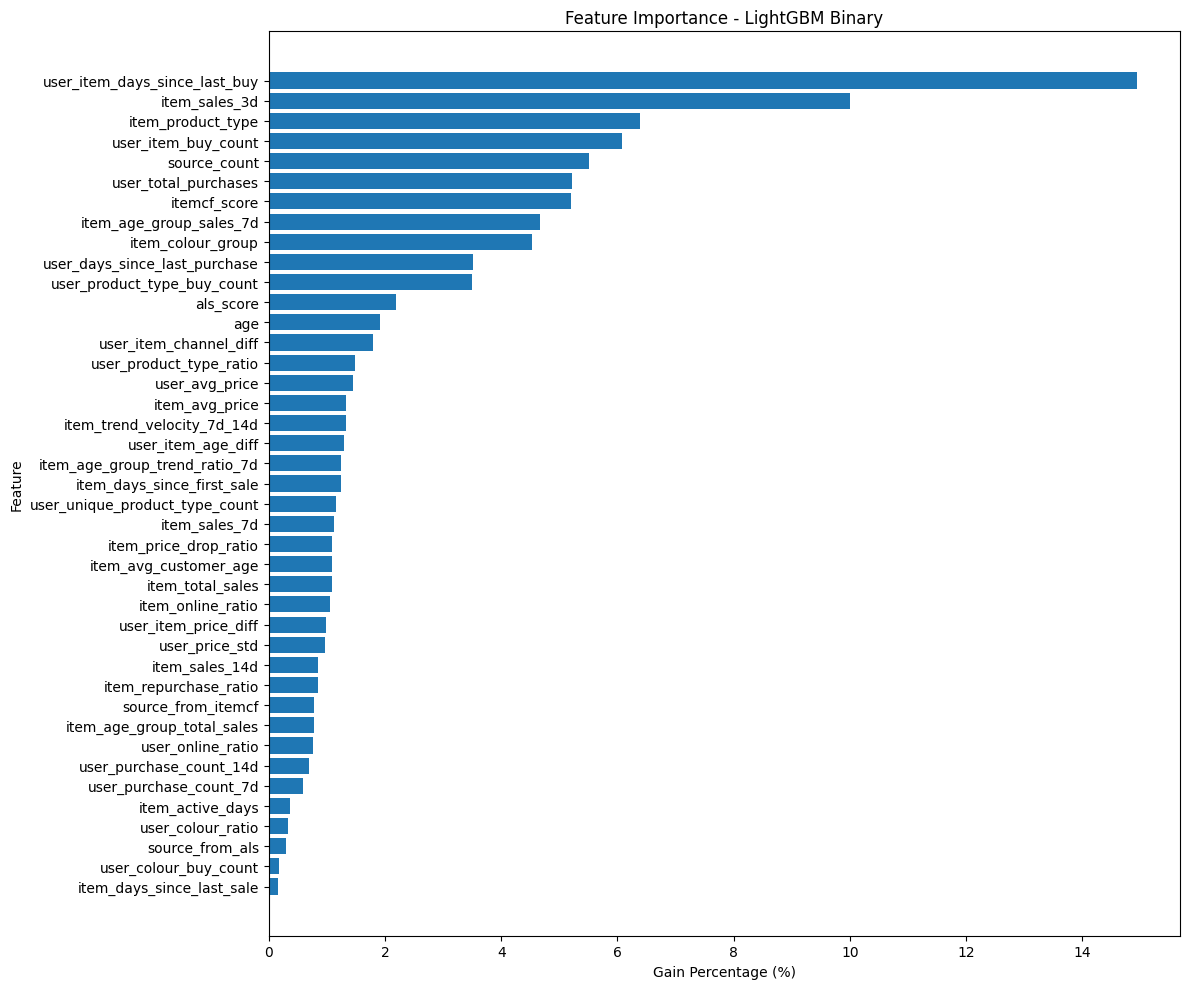

In [ ]:
top_n = min(41, len(df_importance))
plot_df = df_importance.head(top_n).sort_values("importance_percentage")

plt.figure(figsize=(12, 10))
plt.barh(plot_df["feature"], plot_df["importance_percentage"])
plt.title("Feature Importance - LightGBM Binary")
plt.xlabel("Gain Percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
print("Dang du doan test theo batch...")

cols_test = features + ["customer_id", "article_id"]

dataset = ds.dataset(
    TEST_FEATURE_PATH,
    format="parquet",
    ignore_prefixes=[".", "_"]
)

writer = None
batch_count = 0

if os.path.exists(LOCAL_PREDS_PATH):
    os.remove(LOCAL_PREDS_PATH)

for batch in dataset.to_batches(columns=cols_test, batch_size=2_000_000):
    batch_count += 1
    print(f"Dang xu ly batch {batch_count}...")

    df_batch = batch.to_pandas()
    df_batch = downcast_dataframe(df_batch)
    df_batch = prepare_categorical_columns(df_batch, categorical_features)

    df_batch["buy_prob"] = booster.predict(df_batch[features])

    res_batch = df_batch[["customer_id", "article_id", "buy_prob"]]
    table = pa.Table.from_pandas(res_batch, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(LOCAL_PREDS_PATH, table.schema)

    writer.write_table(table)

    del df_batch, res_batch, table, batch
    gc.collect()

if writer is not None:
    writer.close()

del booster
gc.collect()

print("Da du doan xong test.")

Dang du doan test theo batch...
Dang xu ly batch 1...
Dang xu ly batch 2...
Dang xu ly batch 3...
Dang xu ly batch 4...
Dang xu ly batch 5...
Dang xu ly batch 6...
Dang xu ly batch 7...
Dang xu ly batch 8...
Dang xu ly batch 9...
Dang xu ly batch 10...
Dang xu ly batch 11...
Dang xu ly batch 12...
Dang xu ly batch 13...
Dang xu ly batch 14...
Dang xu ly batch 15...
Dang xu ly batch 16...
Dang xu ly batch 17...
Dang xu ly batch 18...
Dang xu ly batch 19...
Dang xu ly batch 20...
Dang xu ly batch 21...
Dang xu ly batch 22...
Dang xu ly batch 23...
Dang xu ly batch 24...
Dang xu ly batch 25...
Dang xu ly batch 26...
Dang xu ly batch 27...
Dang xu ly batch 28...
Dang xu ly batch 29...
Dang xu ly batch 30...
Dang xu ly batch 31...
Dang xu ly batch 32...
Dang xu ly batch 33...
Dang xu ly batch 34...
Dang xu ly batch 35...
Dang xu ly batch 36...
Dang xu ly batch 37...
Dang xu ly batch 38...
Dang xu ly batch 39...
Dang xu ly batch 40...
Dang xu ly batch 41...
Dang xu ly batch 42...
Dang xu ly 

In [ ]:
os.makedirs(os.path.dirname(DRIVE_PREDS_PATH), exist_ok=True)

shutil.copy(LOCAL_PREDS_PATH, DRIVE_PREDS_PATH)

if os.path.exists(LOCAL_PREDS_PATH):
    os.remove(LOCAL_PREDS_PATH)

print("Da luu prediction:", DRIVE_PREDS_PATH)

Da luu prediction: /content/drive/MyDrive/HM-DATA/outputs_v2/predictions/test_predictions_lgbm.parquet


In [ ]:
print("Dang doc ground truth tuan test...")

df_dates = pd.read_parquet(DRIVE_TRANS, columns=["t_dat_date"])
max_date = df_dates["t_dat_date"].max()

test_start = max_date - datetime.timedelta(days=7)
decay_start = test_start - datetime.timedelta(days=21)

del df_dates
gc.collect()

transactions_eval = pd.read_parquet(
    DRIVE_TRANS,
    columns=["t_dat_date", "customer_id", "article_id"],
    filters=[("t_dat_date", ">=", test_start)]
)

actual_grouped = (
    transactions_eval
    .groupby("customer_id")["article_id"]
    .agg(set)
    .reset_index(name="actual_items")
)

del transactions_eval
gc.collect()

print("Max date:", max_date)
print("Test start:", test_start)
print("So khach active:", len(actual_grouped))

Dang doc ground truth tuan test...
Max date: 2020-09-22
Test start: 2020-09-15
So khach active: 75481


In [ ]:
print("Dang tinh time-decayed bestseller...")

customers = pd.read_csv(DRIVE_CUST_RAW, usecols=["customer_id", "age"])

def categorize_age(age):
    if pd.isna(age):
        return "Unknown"
    if age < 25:
        return "<25"
    if age <= 35:
        return "25-35"
    if age <= 45:
        return "36-45"
    if age <= 55:
        return "46-55"
    return ">55"

customers["age_group"] = customers["age"].apply(categorize_age)

trend_df = pd.read_parquet(
    DRIVE_TRANS,
    columns=["t_dat_date", "customer_id", "article_id"],
    filters=[
        ("t_dat_date", ">=", decay_start),
        ("t_dat_date", "<", test_start)
    ]
)

test_start_dt = pd.to_datetime(test_start)

trend_df["days_ago"] = (
    test_start_dt - pd.to_datetime(trend_df["t_dat_date"])
).dt.days

trend_df["weight"] = 0.95 ** trend_df["days_ago"]

global_scores = trend_df.groupby("article_id")["weight"].sum()
global_top_12 = global_scores.nlargest(12).index.tolist()

trend_df = trend_df.merge(
    customers[["customer_id", "age_group"]],
    on="customer_id",
    how="left"
)

trend_df["age_group"] = trend_df["age_group"].fillna("Unknown")

age_scores = (
    trend_df
    .groupby(["age_group", "article_id"])["weight"]
    .sum()
    .reset_index()
)

age_bestsellers = {}

for age_group, group_data in age_scores.groupby("age_group"):
    age_bestsellers[age_group] = (
        group_data
        .nlargest(12, "weight")["article_id"]
        .tolist()
    )

if "Unknown" not in age_bestsellers or len(age_bestsellers["Unknown"]) < 12:
    age_bestsellers["Unknown"] = global_top_12

del trend_df, global_scores, age_scores
gc.collect()

print("Da tinh xong fallback.")

Dang tinh time-decayed bestseller...
Da tinh xong fallback.


In [ ]:
print("Dang doc prediction va lay top 12...")

test_preds = pd.read_parquet(DRIVE_PREDS_PATH)

test_preds = test_preds.sort_values(
    ["customer_id", "buy_prob", "article_id"],
    ascending=[True, False, True]
)

top12_df = test_preds.groupby("customer_id").head(12)

top12_preds = (
    top12_df
    .groupby("customer_id")["article_id"]
    .agg(list)
    .reset_index(name="predicted_items")
)

del test_preds, top12_df
gc.collect()

print("So khach co prediction:", len(top12_preds))

Dang doc prediction va lay top 12...
So khach co prediction: 537866


In [ ]:
print("Dang ghep prediction voi ground truth va fallback...")

eval_df = actual_grouped.merge(
    top12_preds,
    on="customer_id",
    how="left"
)

eval_df = eval_df.merge(
    customers[["customer_id", "age_group"]],
    on="customer_id",
    how="left"
)

eval_df["age_group"] = eval_df["age_group"].fillna("Unknown")

del actual_grouped, top12_preds, customers
gc.collect()


def fill_predictions(row):
    preds = row["predicted_items"]
    age_group = row["age_group"]
    fallback_list = age_bestsellers.get(age_group, global_top_12)

    if not isinstance(preds, list):
        return fallback_list[:12]

    preds = preds[:12]

    if len(preds) < 12:
        needed = 12 - len(preds)

        fillers = [
            item for item in fallback_list
            if item not in preds
        ][:needed]

        if len(fillers) < needed:
            extra_needed = needed - len(fillers)

            extra_fillers = [
                item for item in global_top_12
                if item not in preds and item not in fillers
            ][:extra_needed]

            fillers.extend(extra_fillers)

        preds = preds + fillers

    return preds[:12]


eval_df["predicted_items"] = eval_df.apply(fill_predictions, axis=1)

print("Da hoan tat fallback.")

Dang ghep prediction voi ground truth va fallback...
Da hoan tat fallback.


In [ ]:
def calculate_all_metrics(row, k=12):
    actual = row["actual_items"]
    predicted = row["predicted_items"]

    hits = 0.0
    map_score = 0.0
    dcg = 0.0
    seen = set()

    for i, item in enumerate(predicted[:k]):
        if item in actual and item not in seen:
            hits += 1.0
            map_score += hits / (i + 1)
            dcg += 1.0 / math.log2(i + 2)
            seen.add(item)

    precision = hits / k
    recall = hits / len(actual) if len(actual) > 0 else 0.0
    hit_rate = 1.0 if hits > 0 else 0.0
    map_score = map_score / min(len(actual), k)

    idcg = sum(
        1.0 / math.log2(i + 2)
        for i in range(min(len(actual), k))
    )

    ndcg = dcg / idcg if idcg > 0 else 0.0

    return pd.Series(
        [map_score, ndcg, precision, recall, hit_rate],
        index=["map@12", "ndcg@12", "precision@12", "recall@12", "hit_rate@12"]
    )


print("Dang cham diem...")

metrics_df = eval_df.apply(calculate_all_metrics, axis=1)
eval_df = pd.concat([eval_df, metrics_df], axis=1)

print("Da cham diem xong.")

Dang cham diem...
Da cham diem xong.


In [ ]:
print("\n" + "=" * 70)
print("BANG DIEM DANH GIA DOC LAP - LIGHTGBM BINARY")
print("=" * 70)
print(f"Tong so khach hang active : {len(eval_df):,}")
print("-" * 70)
print(f"MAP@12                    : {eval_df['map@12'].mean():.5f}")
print(f"NDCG@12                   : {eval_df['ndcg@12'].mean():.5f}")
print(f"Precision@12              : {eval_df['precision@12'].mean():.5f}")
print(f"Recall@12                 : {eval_df['recall@12'].mean():.5f}")
print(f"Hit Rate@12               : {eval_df['hit_rate@12'].mean():.2%}")
print("=" * 70)


BANG DIEM DANH GIA DOC LAP - LIGHTGBM BINARY
Tong so khach hang active : 75,481
----------------------------------------------------------------------
MAP@12                    : 0.03056
NDCG@12                   : 0.04462
Precision@12              : 0.01250
Recall@12                 : 0.06308
Hit Rate@12               : 12.35%


In [ ]:
metrics_summary = pd.DataFrame([{
    "num_features": len(features),
    "num_boost_round": num_boost_round,
    "learning_rate": params["learning_rate"],
    "num_leaves": params["num_leaves"],
    "max_depth": params["max_depth"],
    "scale_pos_weight": params["scale_pos_weight"],
    "min_child_samples": params["min_child_samples"],
    "subsample": params["subsample"],
    "colsample_bytree": params["colsample_bytree"],
    "max_bin": params["max_bin"],
    "map@12": eval_df["map@12"].mean(),
    "ndcg@12": eval_df["ndcg@12"].mean(),
    "precision@12": eval_df["precision@12"].mean(),
    "recall@12": eval_df["recall@12"].mean(),
    "hit_rate@12": eval_df["hit_rate@12"].mean()
}])

metrics_summary.to_csv(METRIC_PATH, index=False)

print("Da luu metrics:", METRIC_PATH)
metrics_summary

Da luu metrics: /content/drive/MyDrive/HM-DATA/outputs_v2/models/metrics_lightgbm_binary.csv


,num_features,num_boost_round,learning_rate,num_leaves,max_depth,scale_pos_weight,min_child_samples,subsample,colsample_bytree,max_bin,map@12,ndcg@12,precision@12,recall@12,hit_rate@12
0,41,400,0.02,63,8,7.0,100,0.8,0.8,127,0.030563,0.044624,0.012499,0.063079,0.123501
